# 우송대학교 컴퓨터정보보안전공 202110716 백지원

## **환경적 요인이 건강과 노화에 미치는 영향 분석**

### 데이터 준비

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# 데이터 개수
n = 100

# 랜덤 시드 고정
np.random.seed(0)

# 독립변수 데이터 생성
bmi = np.random.normal(25, 10, n)              # 체질량지수 [kg/m^2]
income = np.random.normal(5000, 1000, n)       # 연평균소득 [만원]
smoking = np.random.choice([0, 1], size=n, p=[0.5, 0.5])
smoking = smoking * np.random.uniform(1, 30, n)  # 흡연기간 [년수]

# 종속변수 데이터 생성. 질병여부(0: 없음, 1: 있음)
disease = (2.0*bmi + 0.01*income + 1.2*smoking + np.random.normal(0, 5, n)) > 100
disease = disease.astype(int)

# 데이터프레임 생성
df = pd.DataFrame({
    'BMI': bmi,
    'Income': income,
    'Smoking': smoking,
    'Disease': disease
})

# 데이터프레임 출력
df.head()



,BMI,Income,Smoking,Disease
0,42.640523,6883.150697,12.387595,1
1,29.001572,3652.240939,0.000000,0
2,34.787380,3729.515002,0.000000,1
3,47.408932,5969.396708,0.000000,1
4,43.675580,3826.876595,0.000000,1


- 종속변수와 독립변수의 데이터 시각화

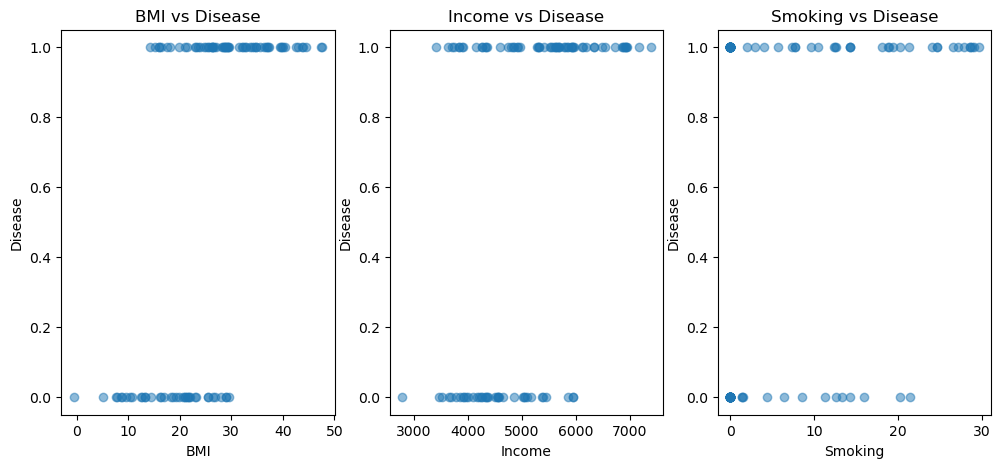

In [2]:
# 시각화 함수 정의
def plotResults(df, x, y, ax):
    # 산점도 그래프 그리기
    ax.scatter(df[x], df[y], alpha=0.5)

    # 제목, x축, y축 레이블 설정
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

# 시각화 함수 호출
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
plotResults(df, 'BMI', 'Disease', ax[0])
plotResults(df, 'Income', 'Disease', ax[1])
plotResults(df, 'Smoking', 'Disease', ax[2])


### 다중선형회귀모형 적용

In [3]:
# 이항 로지스틱회귀모형 적합을 위한 공식 설정
formula_ols = 'Disease ~ BMI + Income + Smoking'

# 이항로지스틱회귀모형 적합. ols() 대신 logit() 사용해야 함
model_ols = smf.ols(formula_ols, data=df).fit()

# 결과 출력
print(model_ols.summary())


                            OLS Regression Results                            
Dep. Variable:                Disease   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     45.52
Date:                Thu, 10 Jul 2025   Prob (F-statistic):           2.19e-18
Time:                        23:45:14   Log-Likelihood:                -25.376
No. Observations:                 100   AIC:                             58.75
Df Residuals:                      96   BIC:                             69.17
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0577      0.172     -6.139      0.0

### 이항 로지스틱회귀모형 적용

In [4]:
# 이항 로지스틱회귀모형 적합을 위한 공식 설정
formula_logit = 'Disease ~ BMI + Income + Smoking'

# 이항로지스틱회귀모형 적합. ols() 대신 logit() 사용
model_logit = smf.logit(formula_logit, data=df).fit()

# 결과 출력
print(model_logit.summary())


Optimization terminated successfully.
         Current function value: 0.052427
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:                Disease   No. Observations:                  100
Model:                          Logit   Df Residuals:                       96
Method:                           MLE   Df Model:                            3
Date:                Thu, 10 Jul 2025   Pseudo R-squ.:                  0.9211
Time:                        23:47:14   Log-Likelihood:                -5.2427
converged:                       True   LL-Null:                       -66.406
Covariance Type:            nonrobust   LLR p-value:                 2.433e-26
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -108.3577     44.759     -2.421      0.015    -196.084     -20.631
BMI            2.3690      0

### 혼동 행렬 시각화

In [6]:
list(zip(group_names, group_counts, group_percents))


[('TN', 37, '37.0%'),
 ('FP', 1, '1.0%'),
 ('FN', 1, '1.0%'),
 ('TP', 61, '61.0%')]

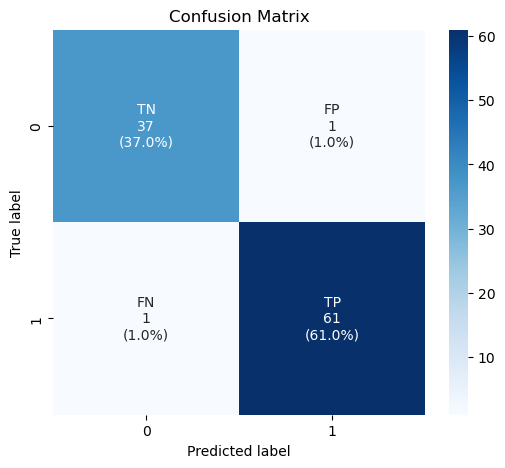

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 예측값 생성
df['Predicted Prob'] = model_logit.predict()
df['predicted'] = df['Predicted Prob'] > 0.5

# 혼동행렬 계산
conf_matrix = confusion_matrix(df['Disease'], df['predicted'])

# 어노테이션 설정
group_names = ["TN", "FP", "FN", "TP"]
group_counts = [value for value in conf_matrix.flatten()]
group_percents = [f'{value:.1%}' for value in conf_matrix.flatten() / np.sum(conf_matrix)]
labels = [f'{v1}\n{v2}\n({v3})' for v1, v2, v3 in zip(group_names, group_counts, group_percents)]
labels = np.asarray(labels).reshape(2, 2)

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=labels, fmt='', cmap='Blues')

plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()



### ROC 곡선 및 AUC 시각화

In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import roc_curve, auc

# accuracy와 roc_auc 측정
print(f'Accuracy: {accuracy_score(df["Disease"], df["predicted"]):0.4f}')
print(f'AUC: {roc_auc_score(df["Disease"], df["predicted"]):0.4f}')


Accuracy: 0.9800
AUC: 0.9788


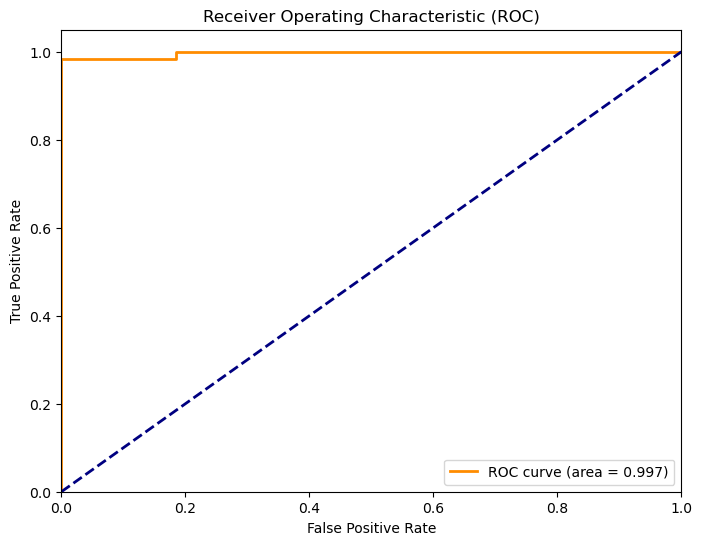

In [9]:
# FPR, TPR, Thresholds 계산
fpr, tpr, thresholds = roc_curve(df['Disease'], df['Predicted Prob'])

# AUC 계산
roc_auc = auc(fpr, tpr)

# ROC Curve 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


## 응용 코드

### 1. 건강 요인들 간의 관계 시각화

- BMI(체질량지수), 소득, 흡연기간은 서로 어떤 관계를 보일지 알아보는 그래프

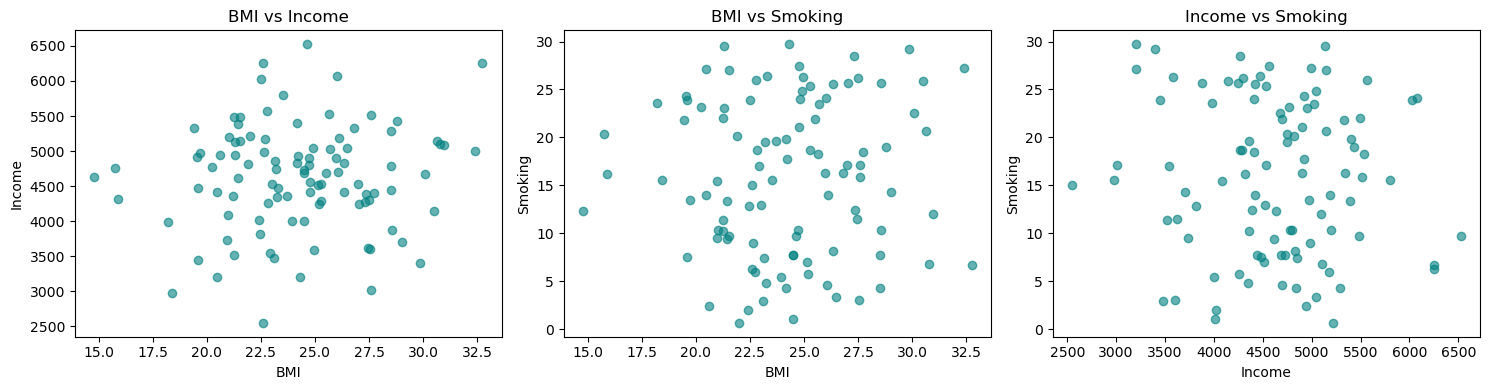

In [2]:
import matplotlib.pyplot as plt

# 시각화 함수 정의
def plotResults(df, x, y, ax):
    ax.scatter(df[x], df[y], alpha=0.6, color='teal')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

# 가상의 건강 데이터 생성
import numpy as np
import pandas as pd
np.random.seed(1)
n = 100
df = pd.DataFrame({
    'BMI': np.random.normal(24, 4, n),
    'Income': np.random.normal(4500, 800, n),
    'Smoking': np.random.uniform(0, 30, n)
})

# 산점도 3개 그리기
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
plotResults(df, 'BMI', 'Income', ax[0])
plotResults(df, 'BMI', 'Smoking', ax[1])
plotResults(df, 'Income', 'Smoking', ax[2])
plt.tight_layout()
plt.show()


### 2. 수면 부족 예측 ROC 곡선 시각화

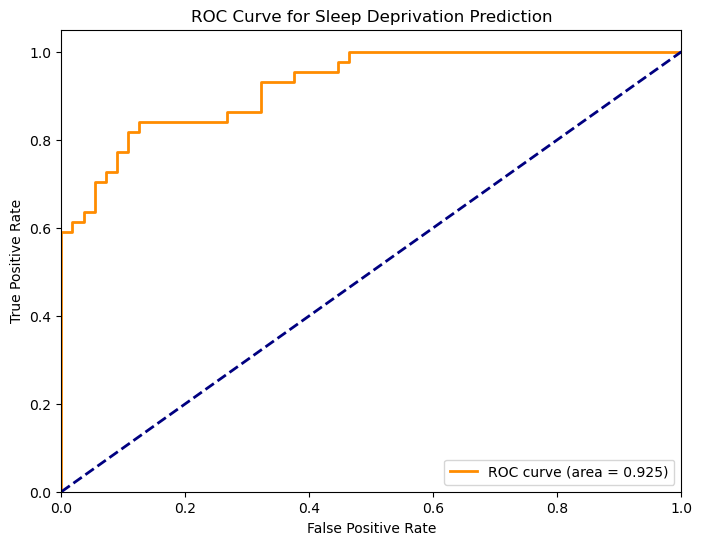

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import statsmodels.formula.api as smf

# 1. 예제 데이터 생성
np.random.seed(0)
n = 100
df = pd.DataFrame({
    'Caffeine': np.random.normal(100, 20, n),
    'Stress': np.random.normal(5, 1.5, n),
    'ScreenTime': np.random.normal(6, 2, n)
})

# 2. 수면 부족 여부 (0 또는 1) 생성
df['SleepDeprived'] = (0.03 * df['Caffeine'] + 0.5 * df['Stress'] + 
                       0.4 * df['ScreenTime'] + np.random.normal(0, 1, n)) > 8
df['SleepDeprived'] = df['SleepDeprived'].astype(int)

# 3. 로지스틱 회귀 모델 학습
formula = 'SleepDeprived ~ Caffeine + Stress + ScreenTime'
model = smf.logit(formula, data=df).fit(disp=False)
df['Predicted_Prob'] = model.predict(df)

# 4. ROC Curve 계산 및 시각화
fpr, tpr, thresholds = roc_curve(df['SleepDeprived'], df['Predicted_Prob'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Sleep Deprivation Prediction')
plt.legend(loc='lower right')
plt.show()
